#### What is Parallelization in LangGraph?
In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. This is achieved by:
- Defining multiple nodes that can operate independently.

- Connecting them to a common starting point (e.g., START or another node).

- Merging their outputs into a downstream node if needed.

LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

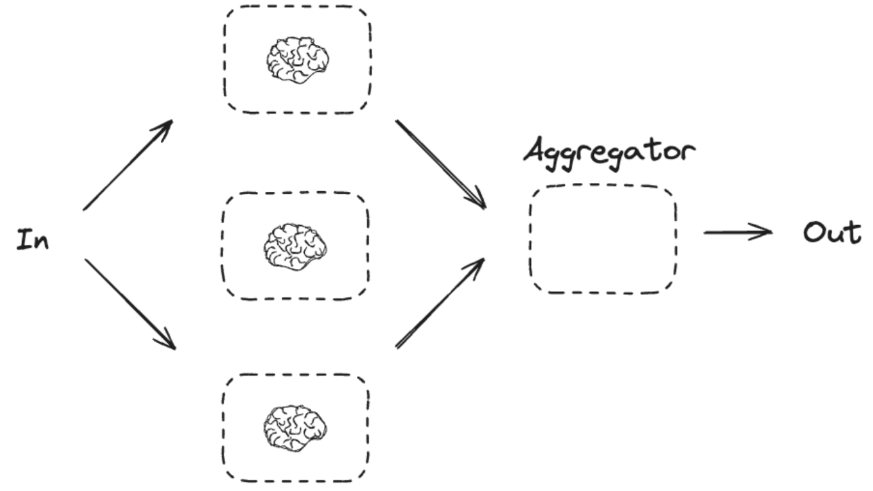

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

#from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#llm=ChatGroq(model="qwen-qwq-32b")
#llm = ChatOpenAI(model="gpt-4o")
llm = ChatOllama(model="qwen2.5:7b")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-17T05:04:52.2591605Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7238735100, 'load_duration': 6106451700, 'prompt_eval_count': 30, 'prompt_eval_duration': 417229500, 'eval_count': 10, 'eval_duration': 700804400, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c69fc-8dd9-7302-bccf-e2ac1a828f82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Graph state
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [3]:
# Nodes
def generate_characters(state: State):
    """Generate character descriptions"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, setting, and premise into an intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )
    return {"story_intro": msg.content}

In [4]:
# Build the graph
graph = StateGraph(State)
graph.add_node("character", generate_characters)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

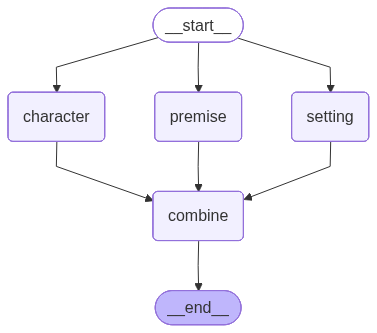

In [5]:
# Define edges (parallel execution from START)
graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")
graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("combine", END)

# Compile and run
compiled_graph = graph.compile()
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [6]:
state = {"topic": "time travel"}
result = compiled_graph.invoke(state)
print(result["story_intro"])

In the heart of a bustling city stands an ancient, weathered clock tower, its hands frozen at 3:17 AM. The streets below are quiet, save for the faint hum of a mysterious energy emanating from the clock's intricate face. This is the entrance to Timekeepers' Lair, a hidden realm where time itself weaves through the corridors and walls.

Evan Hale, a brilliant but troubled physicist, has dedicated his life to unlocking the secrets of time travel. His wife, Sarah, often wonders if their marriage will survive the strain of his relentless experiments. Evan carries a heavy guilt for accidentally causing the death of his best friend in an early experiment, a weight that only grows heavier as he pursues his obsession.

Lia Chen, a historian from the future, ends up being sent back through time when her experimental device malfunctions. Initially skeptical of Evan's theories, she becomes increasingly intrigued by his passion and dedication to time travel. Together, they find themselves at 3:17 

#### Key Benefits
- Speed: Reduces total execution time by running tasks concurrently.

- Scalability: Handles larger workflows efficiently.

- Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
- When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- Merging: Downstream nodes can aggregate parallel results.

- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.

